# EDA DWH Readiness - Fashion Store Analytics

Notebook này kiểm tra dataset **European Fashion Store Multitable Dataset** dưới góc nhìn Data Warehouse:

- Dữ liệu có đủ sạch để load vào DWH không?
- Grain của các fact có đúng không?
- Relationship giữa các bảng có ổn không?
- Các measure revenue, profit, inventory có tính được không?
- Star Schema và dashboard có sẵn sàng chưa?

Notebook được tạo lại từ `scripts/generate_eda_dwh_assets.py`.


In [1]:
# 1. Import libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").exists() and (ROOT.parent / "data" / "raw").exists():
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
REPORT_DIR = ROOT / "reports" / "eda"
REPORT_DIR.mkdir(exist_ok=True)


In [2]:
# 2. Load source CSV tables
FILES = {
    "customers": "dataset_fashion_store_customers.csv",
    "products": "dataset_fashion_store_products.csv",
    "sales": "dataset_fashion_store_sales.csv",
    "salesitems": "dataset_fashion_store_salesitems.csv",
    "stock": "dataset_fashion_store_stock.csv",
    "campaigns": "dataset_fashion_store_campaigns.csv",
    "channels": "dataset_fashion_store_channels.csv",
}

tables = {name: pd.read_csv(RAW_DIR / file_name) for name, file_name in FILES.items()}
{name: df.shape for name, df in tables.items()}


{'customers': (1000, 4),
 'products': (500, 9),
 'sales': (905, 7),
 'salesitems': (2253, 13),
 'stock': (1000, 3),
 'campaigns': (7, 7),
 'channels': (2, 2)}

In [3]:
# 3. Helper functions
def to_num(series):
    return pd.to_numeric(series, errors="coerce")

def to_date(series):
    return pd.to_datetime(series, errors="coerce")

def parse_percent(series):
    return pd.to_numeric(series.astype(str).str.replace("%", "", regex=False).str.strip(), errors="coerce") / 100

def plot_bar(df, x, y, title, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df, x=x, y=y)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

def plot_hist(series, title, bins=30):
    plt.figure(figsize=(9, 4))
    sns.histplot(series.dropna(), bins=bins, kde=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def sample_values(series, mask, limit=5):
    return ", ".join(series[mask.fillna(False)].dropna().astype(str).head(limit).tolist())


,Source Table,Rows,Columns,Primary/Natural Key Candidate,Business Meaning,DWH Role
0,customers,1000,4,customer_id,Customer master data,Dimension source
1,products,500,9,product_id,Product catalog and cost,Dimension source
2,sales,905,7,sale_id,Order header transaction,Fact source
3,salesitems,2253,13,item_id,Order line item transaction,Fact source
4,stock,1000,3,product_id + country,Inventory snapshot,Inventory snapshot source
5,campaigns,7,7,campaign_id,Marketing campaigns,Campaign source
6,channels,2,2,channel,Channel lookup,Lookup source


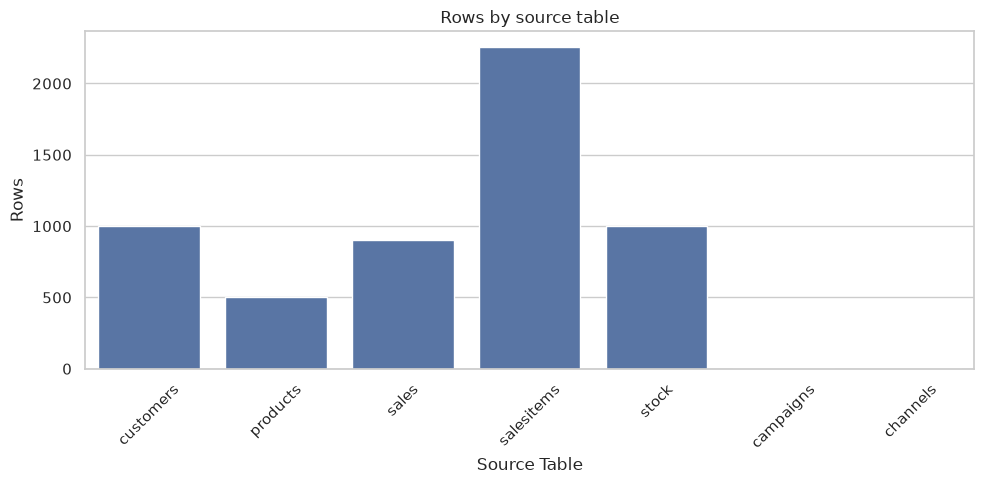

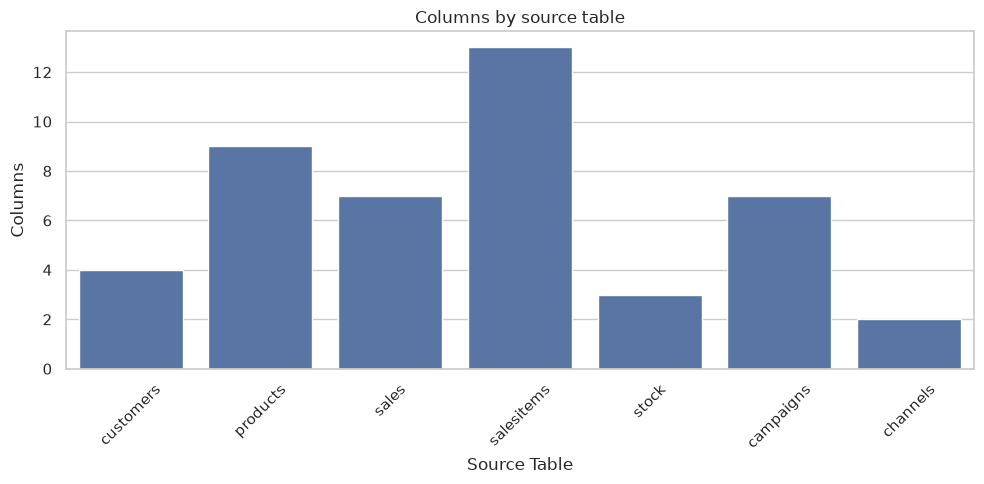

Nhận xét:
- sales là transaction ở cấp đơn hàng, phù hợp tạo fact_order.
- salesitems có grain chi tiết nhất: 1 dòng / 1 sản phẩm trong đơn hàng, phù hợp làm fact_sales chính.
- customers, products, channels, campaigns là nguồn dimension/lookup.
- stock là nguồn inventory snapshot, cần sinh snapshot_date_key vì source không có ngày tồn kho.


In [4]:
# 4. Data overview
role_map = {
    "customers": ("customer_id", "Customer master data", "Dimension source"),
    "products": ("product_id", "Product catalog and cost", "Dimension source"),
    "sales": ("sale_id", "Order header transaction", "Fact source"),
    "salesitems": ("item_id", "Order line item transaction", "Fact source"),
    "stock": ("product_id + country", "Inventory snapshot", "Inventory snapshot source"),
    "campaigns": ("campaign_id", "Marketing campaigns", "Campaign source"),
    "channels": ("channel", "Channel lookup", "Lookup source"),
}

table_overview = pd.DataFrame([
    {
        "Source Table": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Primary/Natural Key Candidate": role_map[name][0],
        "Business Meaning": role_map[name][1],
        "DWH Role": role_map[name][2],
    }
    for name, df in tables.items()
])
display(table_overview)
plot_bar(table_overview, "Source Table", "Rows", "Rows by source table")
plot_bar(table_overview, "Source Table", "Columns", "Columns by source table")

print("""Nhận xét:
- sales là transaction ở cấp đơn hàng, phù hợp tạo fact_order.
- salesitems có grain chi tiết nhất: 1 dòng / 1 sản phẩm trong đơn hàng, phù hợp làm fact_sales chính.
- customers, products, channels, campaigns là nguồn dimension/lookup.
- stock là nguồn inventory snapshot, cần sinh snapshot_date_key vì source không có ngày tồn kho.""")


,Table,Column,Missing Count,Missing Rate,Severity,DWH Impact,Action
0,customers,customer_id,0,0.0,Good,No major impact,Keep
1,customers,country,0,0.0,Good,No major impact,Keep
2,customers,age_range,0,0.0,Good,No major impact,Keep
3,customers,signup_date,0,0.0,Good,No major impact,Keep
4,products,product_id,0,0.0,Good,No major impact,Keep
5,products,product_name,0,0.0,Good,No major impact,Keep
6,products,category,0,0.0,Good,No major impact,Keep
7,products,brand,0,0.0,Good,No major impact,Keep
8,products,color,0,0.0,Good,No major impact,Keep
9,products,size,0,0.0,Good,No major impact,Keep


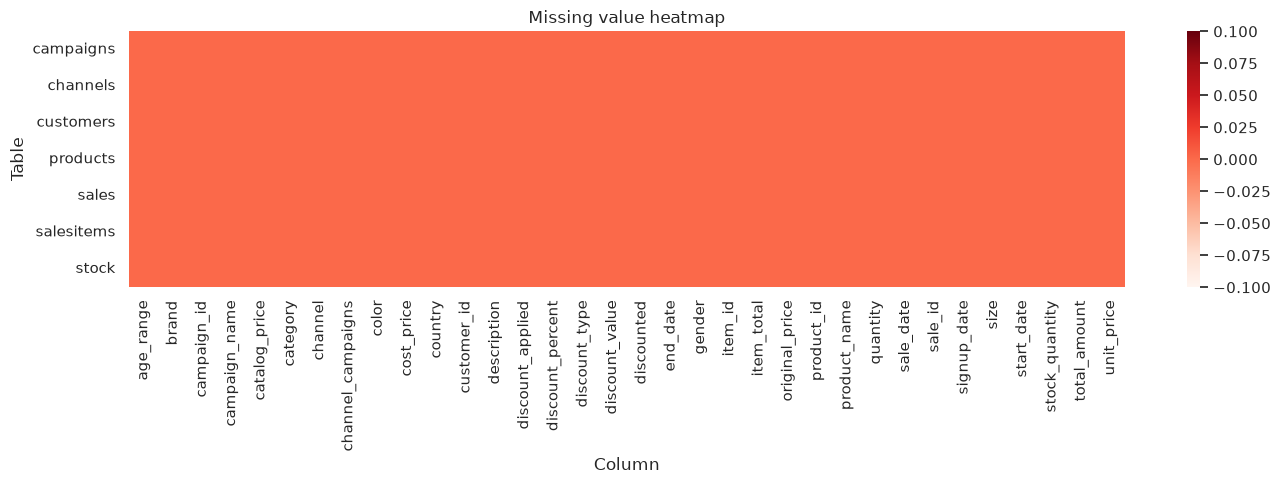

In [5]:
# 5. Missing values
missing_rows = []
for table, df in tables.items():
    for col in df.columns:
        count = int(df[col].isna().sum())
        rate = count / len(df) if len(df) else 0
        severity = "Good" if rate == 0 else "Acceptable" if rate < 0.05 else "Need Review" if rate <= 0.30 else "Serious"
        missing_rows.append({
            "Table": table,
            "Column": col,
            "Missing Count": count,
            "Missing Rate": rate,
            "Severity": severity,
            "DWH Impact": "No major impact" if count == 0 else "Need Unknown member or quarantine",
            "Action": "Keep" if count == 0 else "Review before DWH load",
        })
missing_values = pd.DataFrame(missing_rows)
display(missing_values.sort_values(["Missing Rate", "Missing Count"], ascending=False).head(20))

missing_pivot = missing_values.pivot(index="Table", columns="Column", values="Missing Rate").fillna(0)
plt.figure(figsize=(14, 5))
sns.heatmap(missing_pivot, cmap="Reds", annot=False)
plt.title("Missing value heatmap")
plt.tight_layout()
plt.show()


,Table,Key Checked,Duplicate Count,Duplicate Rate,DWH Impact,Recommended Action
0,customers,customer_id,0,0.0,No issue,Keep
1,products,product_id,0,0.0,No issue,Keep
2,sales,sale_id,0,0.0,No issue,Keep
3,salesitems,item_id,0,0.0,No issue,Keep
4,campaigns,campaign_id,0,0.0,No issue,Keep
5,stock,product_id + country,0,0.0,No issue,Keep


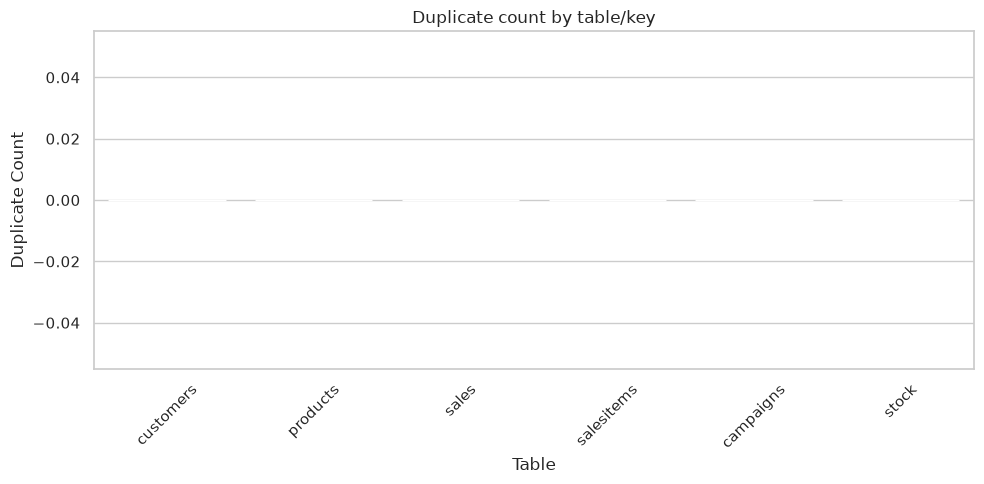

In [6]:
# 6. Duplicate key checks
duplicate_specs = {
    "customers": ["customer_id"],
    "products": ["product_id"],
    "sales": ["sale_id"],
    "salesitems": ["item_id"],
    "campaigns": ["campaign_id"],
    "stock": ["product_id", "country"],
}

duplicate_checks = []
for table, keys in duplicate_specs.items():
    df = tables[table]
    count = int(df.duplicated(keys, keep=False).sum())
    duplicate_checks.append({
        "Table": table,
        "Key Checked": " + ".join(keys),
        "Duplicate Count": count,
        "Duplicate Rate": count / len(df),
        "DWH Impact": "Can break fact/dimension grain" if count else "No issue",
        "Recommended Action": "Deduplicate/quarantine" if count else "Keep",
    })
duplicate_checks = pd.DataFrame(duplicate_checks)
display(duplicate_checks)
plot_bar(duplicate_checks, "Table", "Duplicate Count", "Duplicate count by table/key")


,Relationship,Source Rows,Matched Rows,Unmatched Rows,Match Rate,Status
0,sales.customer_id -> customers.customer_id,905,905,0,1.0,OK
1,salesitems.sale_id -> sales.sale_id,2253,2253,0,1.0,OK
2,salesitems.product_id -> products.product_id,2253,2253,0,1.0,OK
3,stock.product_id -> products.product_id,1000,1000,0,1.0,OK
4,sales.country -> geography list,905,905,0,1.0,OK
5,customers.country -> geography list,1000,1000,0,1.0,OK
6,stock.country -> geography list,1000,1000,0,1.0,OK
7,sales.channel -> channel dimension,905,905,0,1.0,OK
8,salesitems.channel -> channel dimension,2253,2253,0,1.0,OK
9,campaigns.channel -> channel dimension,7,7,0,1.0,OK


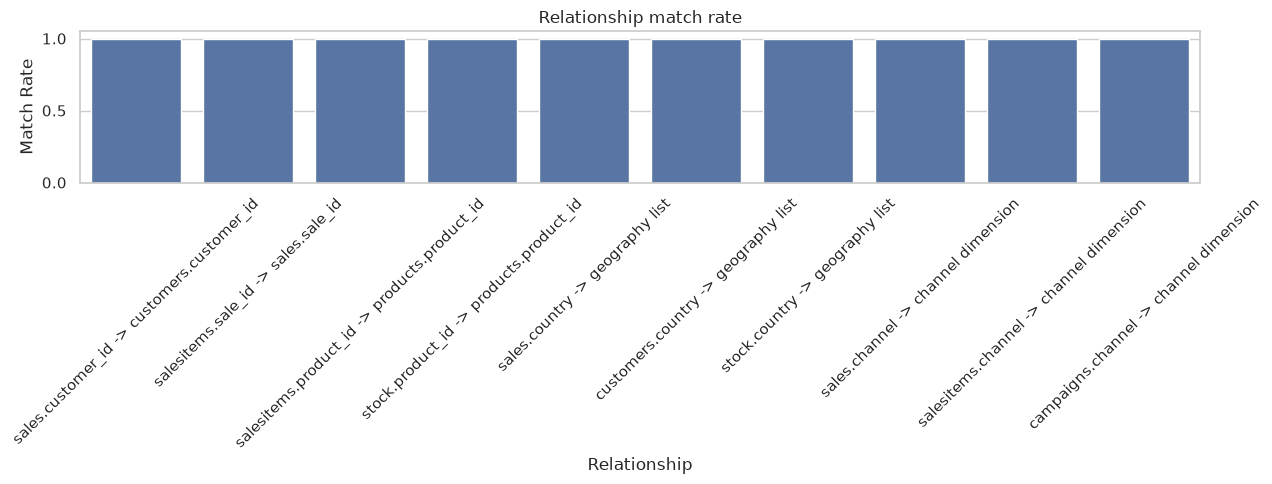

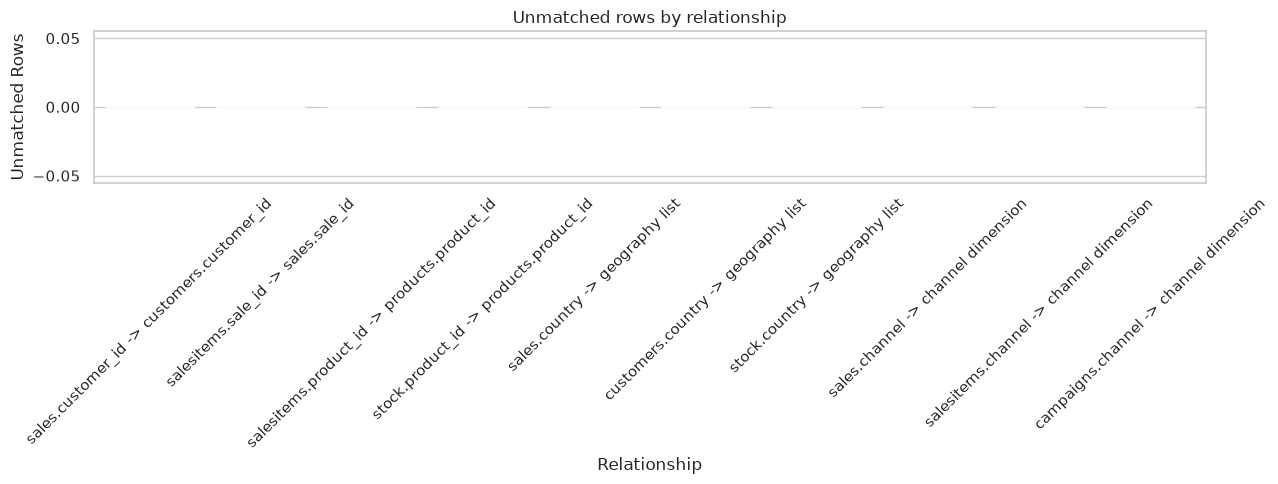

In [7]:
# 7. Relationship validation
customers = tables["customers"]
products = tables["products"]
sales = tables["sales"]
items = tables["salesitems"]
stock = tables["stock"]
campaigns = tables["campaigns"]
channels = tables["channels"]

geography = pd.Series(pd.concat([customers["country"], sales["country"], stock["country"]]).dropna().unique())
channel_dim = pd.Series(pd.concat([channels["channel"], sales["channel"], items["channel"], campaigns["channel"]]).dropna().unique())

relationship_specs = [
    ("sales.customer_id -> customers.customer_id", sales["customer_id"], customers["customer_id"]),
    ("salesitems.sale_id -> sales.sale_id", items["sale_id"], sales["sale_id"]),
    ("salesitems.product_id -> products.product_id", items["product_id"], products["product_id"]),
    ("stock.product_id -> products.product_id", stock["product_id"], products["product_id"]),
    ("sales.country -> geography list", sales["country"], geography),
    ("customers.country -> geography list", customers["country"], geography),
    ("stock.country -> geography list", stock["country"], geography),
    ("sales.channel -> channel dimension", sales["channel"], channel_dim),
    ("salesitems.channel -> channel dimension", items["channel"], channel_dim),
    ("campaigns.channel -> channel dimension", campaigns["channel"], channel_dim),
]

relationship_checks = []
for rel, src, tgt in relationship_specs:
    matched = int(src.isin(set(tgt.dropna())).sum())
    relationship_checks.append({
        "Relationship": rel,
        "Source Rows": len(src),
        "Matched Rows": matched,
        "Unmatched Rows": len(src) - matched,
        "Match Rate": matched / len(src),
        "Status": "OK" if matched == len(src) else "Need Review",
    })
relationship_checks = pd.DataFrame(relationship_checks)
display(relationship_checks)
plot_bar(relationship_checks, "Relationship", "Match Rate", "Relationship match rate", figsize=(13, 5))
plot_bar(relationship_checks, "Relationship", "Unmatched Rows", "Unmatched rows by relationship", figsize=(13, 5))


In [8]:
# 8. Grain validation
grain_validation = pd.DataFrame([
    {
        "Table": "sales",
        "Expected Grain": "1 row / sale_id",
        "Key Unique": not sales["sale_id"].duplicated().any(),
        "Null Key Count": int(sales["sale_id"].isna().sum()),
        "Notes": "Suitable for fact_order",
    },
    {
        "Table": "salesitems",
        "Expected Grain": "1 row / item_id",
        "Key Unique": not items["item_id"].duplicated().any(),
        "Null Key Count": int(items["item_id"].isna().sum()),
        "Notes": "Main source for fact_sales",
    },
    {
        "Table": "stock",
        "Expected Grain": "1 row / product_id + country + snapshot_date_key",
        "Key Unique": not stock.duplicated(["product_id", "country"]).any(),
        "Null Key Count": int(stock[["product_id", "country"]].isna().any(axis=1).sum()),
        "Notes": "Needs generated snapshot_date_key",
    },
])
display(grain_validation)

items_per_sale = items.groupby("sale_id").size().describe()
display(items_per_sale)


,Table,Expected Grain,Key Unique,Null Key Count,Notes
0,sales,1 row / sale_id,True,0,Suitable for fact_order
1,salesitems,1 row / item_id,True,0,Main source for fact_sales
2,stock,1 row / product_id + country + snapshot_date_key,True,0,Needs generated snapshot_date_key


count    905.000000
mean       2.489503
std        0.500166
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
dtype: float64

,Table,Rule,Invalid Count,Invalid Rate,Example Values,DWH Impact,Action
11,salesitems,item_total != quantity * unit_price,77,0.034177,"2251, 1486, 1194, 2367, 3244",Bad net amount,Flag/recalculate
1,customers,signup_date invalid,0,0.000000,,No issue,Keep
0,customers,customer_id null,0,0.000000,,No issue,Keep
3,products,catalog_price <= 0,0,0.000000,,No issue,Keep
4,products,cost_price < 0,0,0.000000,,No issue,Keep
5,products,cost_price > catalog_price,0,0.000000,,No issue,Keep
2,customers,country null,0,0.000000,,No issue,Keep
6,sales,customer_id not in customers,0,0.000000,,No issue,Keep
7,sales,total_amount < 0,0,0.000000,,No issue,Keep
9,salesitems,product_id not in products,0,0.000000,,No issue,Keep


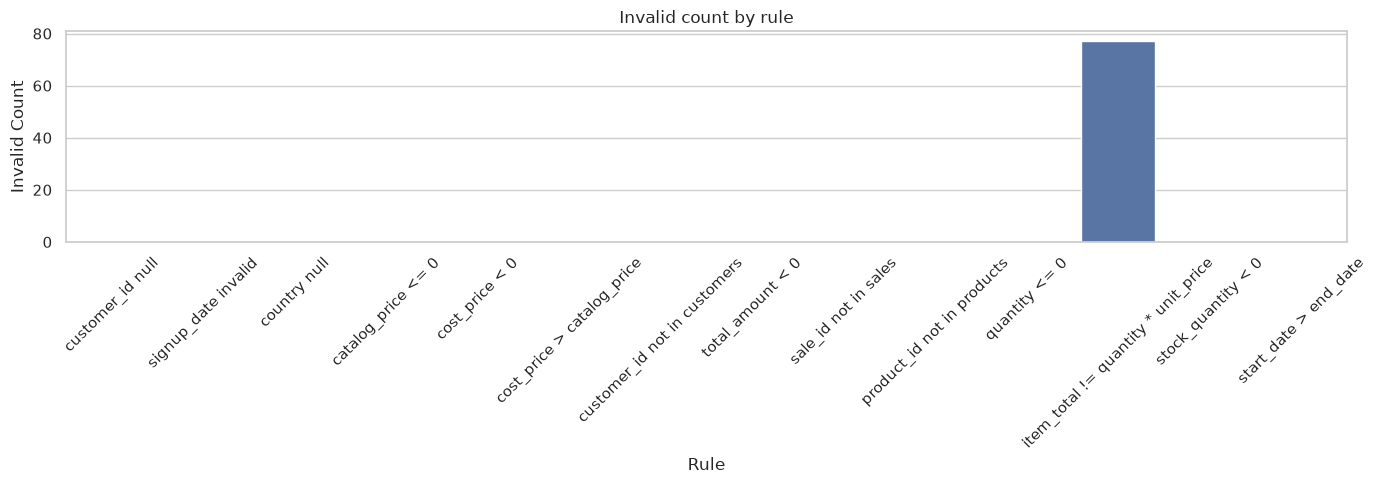

In [9]:
# 9. Invalid value checks
invalid_rows = []

def add_invalid(table, rule, mask, examples, impact, action):
    mask = mask.fillna(False)
    count = int(mask.sum())
    invalid_rows.append({
        "Table": table,
        "Rule": rule,
        "Invalid Count": count,
        "Invalid Rate": count / len(mask) if len(mask) else 0,
        "Example Values": sample_values(examples, mask),
        "DWH Impact": impact if count else "No issue",
        "Action": action if count else "Keep",
    })

add_invalid("customers", "customer_id null", customers["customer_id"].isna(), customers["customer_id"], "Cannot build dim_customer", "Quarantine")
add_invalid("customers", "signup_date invalid", to_date(customers["signup_date"]).isna(), customers["signup_date"], "Bad date key", "Quarantine")
add_invalid("customers", "country null", customers["country"].isna(), customers["country"], "Bad geography lookup", "Unknown member")
add_invalid("products", "catalog_price <= 0", to_num(products["catalog_price"]) <= 0, products["catalog_price"], "Bad price", "Review")
add_invalid("products", "cost_price < 0", to_num(products["cost_price"]) < 0, products["cost_price"], "Bad cost", "Review")
add_invalid("products", "cost_price > catalog_price", to_num(products["cost_price"]) > to_num(products["catalog_price"]), products["product_id"], "Bad margin", "Review")
add_invalid("sales", "customer_id not in customers", ~sales["customer_id"].isin(customers["customer_id"]), sales["customer_id"], "Bad customer FK", "Quarantine/Unknown")
add_invalid("sales", "total_amount < 0", to_num(sales["total_amount"]) < 0, sales["total_amount"], "Bad revenue", "Quarantine")
add_invalid("salesitems", "sale_id not in sales", ~items["sale_id"].isin(sales["sale_id"]), items["sale_id"], "Bad order FK", "Quarantine")
add_invalid("salesitems", "product_id not in products", ~items["product_id"].isin(products["product_id"]), items["product_id"], "Bad product FK", "Quarantine/Unknown")
add_invalid("salesitems", "quantity <= 0", to_num(items["quantity"]) <= 0, items["quantity"], "Bad quantity", "Quarantine")
expected_total = to_num(items["quantity"]) * to_num(items["unit_price"])
add_invalid("salesitems", "item_total != quantity * unit_price", (to_num(items["item_total"]) - expected_total).abs() > 0.01, items["item_id"], "Bad net amount", "Flag/recalculate")
add_invalid("stock", "product_id not in products", ~stock["product_id"].isin(products["product_id"]), stock["product_id"], "Bad product FK", "Quarantine")
add_invalid("stock", "stock_quantity < 0", to_num(stock["stock_quantity"]) < 0, stock["stock_quantity"], "Bad inventory", "Quarantine")
add_invalid("campaigns", "start_date > end_date", to_date(campaigns["start_date"]) > to_date(campaigns["end_date"]), campaigns["campaign_id"], "Bad campaign period", "Review")

invalid_values = pd.DataFrame(invalid_rows)
display(invalid_values.sort_values("Invalid Count", ascending=False))
plot_bar(invalid_values, "Rule", "Invalid Count", "Invalid count by rule", figsize=(14, 5))


,Total orders,Reconciled orders,Unreconciled orders,Reconciliation rate,Total absolute difference
0,905,905,0,1.0,9.549694e-12


,sale_id,total_amount,sum_item_total,amount_diff,is_reconciled
746,790,639.14,639.14,-1.136868e-13,True
698,72,622.14,622.14,-1.136868e-13,True
694,715,512.83,512.83,1.136868e-13,True
613,601,542.92,542.92,-1.136868e-13,True
227,130,553.92,553.92,-1.136868e-13,True
426,349,523.43,523.43,-1.136868e-13,True
433,357,548.56,548.56,-1.136868e-13,True
351,250,581.85,581.85,1.136868e-13,True
359,260,528.34,528.34,1.136868e-13,True
333,229,543.17,543.17,-1.136868e-13,True


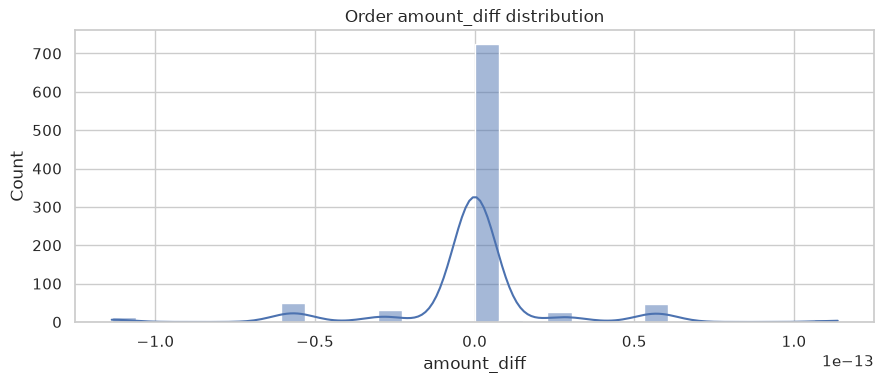

In [10]:
# 10. Reconciliation checks
sales_amount = sales[["sale_id", "total_amount"]].copy()
sales_amount["total_amount"] = to_num(sales_amount["total_amount"])
item_sum = items.assign(item_total_num=to_num(items["item_total"])).groupby("sale_id", as_index=False)["item_total_num"].sum()
item_sum = item_sum.rename(columns={"item_total_num": "sum_item_total"})
reconciliation = sales_amount.merge(item_sum, on="sale_id", how="left")
reconciliation["sum_item_total"] = reconciliation["sum_item_total"].fillna(0)
reconciliation["amount_diff"] = reconciliation["total_amount"] - reconciliation["sum_item_total"]
reconciliation["is_reconciled"] = reconciliation["amount_diff"].abs() <= 0.01

rec_kpi = pd.DataFrame([{
    "Total orders": len(reconciliation),
    "Reconciled orders": int(reconciliation["is_reconciled"].sum()),
    "Unreconciled orders": int((~reconciliation["is_reconciled"]).sum()),
    "Reconciliation rate": reconciliation["is_reconciled"].mean(),
    "Total absolute difference": reconciliation["amount_diff"].abs().sum(),
}])
display(rec_kpi)
display(reconciliation.sort_values("amount_diff", key=lambda s: s.abs(), ascending=False).head(20))
plot_hist(reconciliation["amount_diff"], "Order amount_diff distribution")


,category,revenue,gross_profit
2,Shoes,70074.00,30473.46
4,T-Shirts,69692.78,30782.64
0,Dresses,68390.64,29846.75
3,Sleepwear,62276.58,26000.55
1,Pants,53802.66,24049.89


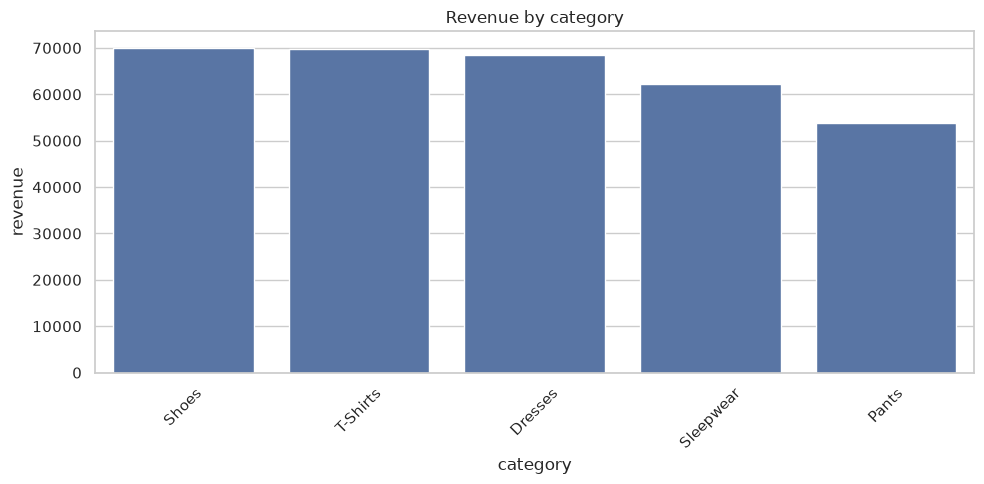

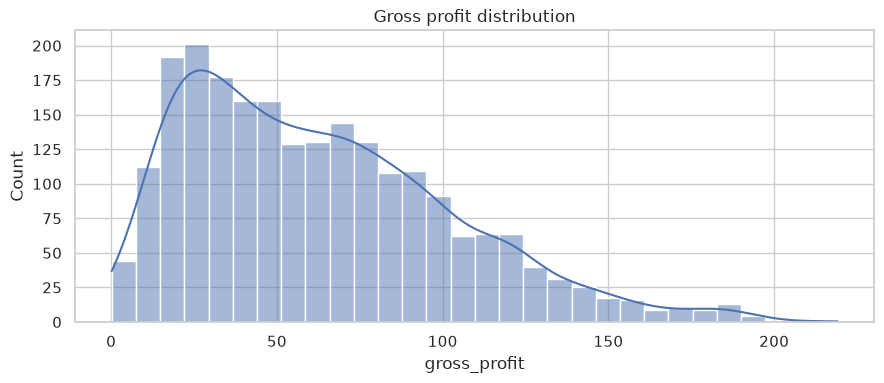

In [11]:
# 11. Fact_sales measure readiness
fact_sales_preview = items.merge(products[["product_id", "category", "brand", "cost_price"]], on="product_id", how="left")
for col in ["quantity", "original_price", "unit_price", "discount_applied", "item_total", "cost_price"]:
    fact_sales_preview[col] = to_num(fact_sales_preview[col])
fact_sales_preview["discount_percent_num"] = parse_percent(fact_sales_preview["discount_percent"])
fact_sales_preview["gross_amount"] = fact_sales_preview["quantity"] * fact_sales_preview["original_price"]
fact_sales_preview["net_amount"] = fact_sales_preview["item_total"]
fact_sales_preview["calculated_net_amount"] = fact_sales_preview["quantity"] * fact_sales_preview["unit_price"]
fact_sales_preview["discount_amount"] = fact_sales_preview["gross_amount"] - fact_sales_preview["net_amount"]
fact_sales_preview["cost_amount"] = fact_sales_preview["quantity"] * fact_sales_preview["cost_price"]
fact_sales_preview["gross_profit"] = fact_sales_preview["net_amount"] - fact_sales_preview["cost_amount"]
fact_sales_preview["gross_margin"] = np.where(fact_sales_preview["net_amount"].ne(0), fact_sales_preview["gross_profit"] / fact_sales_preview["net_amount"], np.nan)

category_revenue = fact_sales_preview.groupby("category", as_index=False).agg(revenue=("net_amount", "sum"), gross_profit=("gross_profit", "sum"))
display(category_revenue.sort_values("revenue", ascending=False))
plot_bar(category_revenue.sort_values("revenue", ascending=False), "category", "revenue", "Revenue by category")
plot_hist(fact_sales_preview["gross_profit"], "Gross profit distribution")


In [12]:
# 12. Outlier analysis
outlier_rows = []
frames = {
    "salesitems": fact_sales_preview[["quantity", "original_price", "unit_price", "item_total", "discount_applied", "discount_percent_num", "gross_profit", "gross_margin"]],
    "sales": sales[["total_amount"]].apply(to_num),
    "stock": stock[["stock_quantity"]].apply(to_num),
}

for table, df in frames.items():
    for col in df.columns:
        x = to_num(df[col]).dropna()
        if x.empty:
            continue
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = int(((x < low) | (x > high)).sum())
        outlier_rows.append({
            "Table": table,
            "Column": col,
            "Min": x.min(),
            "Q1": q1,
            "Median": x.median(),
            "Mean": x.mean(),
            "Q3": q3,
            "Max": x.max(),
            "P01": x.quantile(0.01),
            "P99": x.quantile(0.99),
            "Outlier Count": outliers,
            "Outlier Rate": outliers / len(x),
            "DWH Action": "Flag only" if outliers else "Keep",
        })
outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.sort_values("Outlier Rate", ascending=False))


,Table,Column,Min,Q1,Median,Mean,Q3,Max,P01,P99,Outlier Count,Outlier Rate,DWH Action
4,salesitems,discount_applied,0.000000,0.000000,0.000000,1.180129,0.000000,24.510000,0.00000,19.207200,222,0.098535,Flag only
5,salesitems,discount_percent_num,0.000000,0.000000,0.000000,0.023968,0.000000,0.300000,0.00000,0.300000,222,0.098535,Flag only
7,salesitems,gross_margin,0.004317,0.358901,0.432415,0.431980,0.520392,0.598581,0.04203,0.597176,42,0.018642,Flag only
6,salesitems,gross_profit,0.160000,29.980000,56.550000,62.651261,87.900000,219.150000,4.05840,180.012000,31,0.013759,Flag only
8,sales,total_amount,45.500000,241.040000,343.780000,358.272552,452.650000,859.380000,79.04040,740.227600,5,0.005525,Flag only
3,salesitems,item_total,13.510000,74.700000,130.500000,143.913298,198.750000,403.800000,25.43600,360.500000,8,0.003551,Flag only
2,salesitems,unit_price,11.680000,38.490000,47.730000,48.141074,57.350000,85.900000,20.56560,79.844000,1,0.000444,Flag only
0,salesitems,quantity,1.000000,2.000000,3.000000,2.980470,4.000000,5.000000,1.00000,5.000000,0,0.000000,Keep
1,salesitems,original_price,13.510000,39.340000,49.760000,49.321185,58.340000,85.900000,21.45800,80.760000,0,0.000000,Keep
9,stock,stock_quantity,1.000000,1.000000,1.000000,24.636000,48.000000,99.000000,1.00000,99.000000,0,0.000000,Keep


In [13]:
# 13. DWH mapping and readiness
dwh_mapping = pd.DataFrame([
    ["customers", "customer_id", "dim_customer", "customer_id", "cast integer", "quarantine if null/duplicate"],
    ["customers", "country", "dim_geography", "country", "trim/title case", "unknown member if null"],
    ["products", "product_id", "dim_product", "product_id", "cast integer", "quarantine if null/duplicate"],
    ["sales", "sale_id", "fact_order", "sale_id", "cast integer", "quarantine if null/duplicate"],
    ["salesitems + products", "quantity,prices,cost_price", "fact_sales", "gross/net/cost/profit measures", "calculate with pandas", "flag amount mismatch"],
    ["stock", "product_id,country,stock_quantity", "fact_inventory", "product_key,geography_key,stock_quantity", "lookup keys, cast integer", "quarantine if negative/unmatched"],
], columns=["Source Table", "Source Column", "Target Table", "Target Column", "Transform Rule", "Data Quality Rule"])

dimension_readiness = pd.DataFrame([
    ["dim_date", "all date columns", "full_date", "date_key", "calendar attributes", "None", "Generate from source min/max dates"],
    ["dim_customer", "customers", "customer_id", "customer_key", "country, age_range, signup_date", "Type 1", "Ready"],
    ["dim_product", "products", "product_id", "product_key", "category, brand, price, cost", "Type 2 optional", "Ready"],
    ["dim_geography", "customers/sales/stock", "country", "geography_key", "country, region", "Type 1", "Ready"],
    ["dim_channel", "channels/sales/salesitems/campaigns", "channel_name", "channel_key", "description, channel_type", "Type 1", "Union all sources"],
    ["dim_campaign", "campaigns", "campaign_id", "campaign_key", "campaign attributes", "Type 1", "Campaign mapping sparse"],
], columns=["Dimension", "Source", "Natural Key", "Surrogate Key", "Important Attributes", "SCD Type", "Data Quality Notes"])

fact_readiness = pd.DataFrame([
    ["fact_order", "sales", "1 row / sale_id", "sale_date_key, customer_key, geography_key, channel_key", "order_count,total_amount,line_item_count", "Additive; AOV derived", "Ready"],
    ["fact_sales", "salesitems + sales + products", "1 row / item_id", "date/customer/product/geography/channel/campaign", "quantity,gross,net,discount,cost,profit", "Main additive measures", "Ready"],
    ["fact_inventory", "stock + products", "product_id + country + snapshot_date_key", "snapshot_date_key, product_key, geography_key", "stock_quantity, stock_value", "Semi-additive", "Needs snapshot_date_key"],
    ["fact_customer_activity", "customers + sales", "customer + activity_date", "activity_date_key, customer_key, geography_key", "signup_count, order_count, revenue", "Additive", "Optional"],
], columns=["Fact Table", "Source", "Grain", "Foreign Keys", "Measures", "Additivity", "Data Quality Notes"])

display(dwh_mapping)
display(dimension_readiness)
display(fact_readiness)


,Source Table,Source Column,Target Table,Target Column,Transform Rule,Data Quality Rule
0,customers,customer_id,dim_customer,customer_id,cast integer,quarantine if null/duplicate
1,customers,country,dim_geography,country,trim/title case,unknown member if null
2,products,product_id,dim_product,product_id,cast integer,quarantine if null/duplicate
3,sales,sale_id,fact_order,sale_id,cast integer,quarantine if null/duplicate
4,salesitems + products,"quantity,prices,cost_price",fact_sales,gross/net/cost/profit measures,calculate with pandas,flag amount mismatch
5,stock,"product_id,country,stock_quantity",fact_inventory,"product_key,geography_key,stock_quantity","lookup keys, cast integer",quarantine if negative/unmatched


,Dimension,Source,Natural Key,Surrogate Key,Important Attributes,SCD Type,Data Quality Notes
0,dim_date,all date columns,full_date,date_key,calendar attributes,None,Generate from source min/max dates
1,dim_customer,customers,customer_id,customer_key,"country, age_range, signup_date",Type 1,Ready
2,dim_product,products,product_id,product_key,"category, brand, price, cost",Type 2 optional,Ready
3,dim_geography,customers/sales/stock,country,geography_key,"country, region",Type 1,Ready
4,dim_channel,channels/sales/salesitems/campaigns,channel_name,channel_key,"description, channel_type",Type 1,Union all sources
5,dim_campaign,campaigns,campaign_id,campaign_key,campaign attributes,Type 1,Campaign mapping sparse


,Fact Table,Source,Grain,Foreign Keys,Measures,Additivity,Data Quality Notes
0,fact_order,sales,1 row / sale_id,"sale_date_key, customer_key, geography_key, ch...","order_count,total_amount,line_item_count",Additive; AOV derived,Ready
1,fact_sales,salesitems + sales + products,1 row / item_id,date/customer/product/geography/channel/campaign,"quantity,gross,net,discount,cost,profit",Main additive measures,Ready
2,fact_inventory,stock + products,product_id + country + snapshot_date_key,"snapshot_date_key, product_key, geography_key","stock_quantity, stock_value",Semi-additive,Needs snapshot_date_key
3,fact_customer_activity,customers + sales,customer + activity_date,"activity_date_key, customer_key, geography_key","signup_count, order_count, revenue",Additive,Optional


In [14]:
# 14. Dashboard readiness
dashboard_readiness = pd.DataFrame([
    ["Total Revenue", "fact_order/fact_sales", "total_amount/net_amount", "Yes", "Use correct grain", "Ready"],
    ["Orders", "fact_order", "order_count", "Yes", "None", "Ready"],
    ["AOV", "fact_order", "total_amount/order_count", "Yes", "Avoid fact-to-fact join", "Ready"],
    ["Quantity Sold", "fact_sales", "quantity", "Yes", "None", "Ready"],
    ["Gross Profit", "fact_sales", "gross_profit", "Yes", "Cost available", "Ready"],
    ["Inventory Quantity", "fact_inventory", "stock_quantity", "Yes", "Semi-additive", "Filter snapshot date"],
    ["Campaign Performance", "fact_sales + dim_campaign", "campaign_key", "Partial", "Mapping sparse", "Allow nullable campaign_key"],
], columns=["KPI", "Required Fact", "Required Columns", "Can Calculate?", "Data Issue", "Recommendation"])
display(dashboard_readiness)


,KPI,Required Fact,Required Columns,Can Calculate?,Data Issue,Recommendation
0,Total Revenue,fact_order/fact_sales,total_amount/net_amount,Yes,Use correct grain,Ready
1,Orders,fact_order,order_count,Yes,None,Ready
2,AOV,fact_order,total_amount/order_count,Yes,Avoid fact-to-fact join,Ready
3,Quantity Sold,fact_sales,quantity,Yes,None,Ready
4,Gross Profit,fact_sales,gross_profit,Yes,Cost available,Ready
5,Inventory Quantity,fact_inventory,stock_quantity,Yes,Semi-additive,Filter snapshot date
6,Campaign Performance,fact_sales + dim_campaign,campaign_key,Partial,Mapping sparse,Allow nullable campaign_key


In [15]:
# 15. Export EDA outputs to Excel
excel_path = REPORT_DIR / "fashion_store_eda_dwh_results_from_notebook.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    table_overview.to_excel(writer, sheet_name="table_overview", index=False)
    missing_values.to_excel(writer, sheet_name="missing_values", index=False)
    duplicate_checks.to_excel(writer, sheet_name="duplicate_checks", index=False)
    relationship_checks.to_excel(writer, sheet_name="relationship_checks", index=False)
    invalid_values.to_excel(writer, sheet_name="invalid_values", index=False)
    outlier_summary.to_excel(writer, sheet_name="outlier_summary", index=False)
    reconciliation.to_excel(writer, sheet_name="reconciliation", index=False)
    dwh_mapping.to_excel(writer, sheet_name="dwh_mapping", index=False)
    dimension_readiness.to_excel(writer, sheet_name="dimension_readiness", index=False)
    fact_readiness.to_excel(writer, sheet_name="fact_readiness", index=False)
    dashboard_readiness.to_excel(writer, sheet_name="dashboard_readiness", index=False)
excel_path


PosixPath('/app/reports/eda/fashion_store_eda_dwh_results_from_notebook.xlsx')

## Final conclusion

- Dataset đủ điều kiện triển khai DWH dạng Star Schema.
- `salesitems` là fact chính cho phân tích sales line.
- `sales` nên tách riêng thành `fact_order` để tính Orders/AOV đúng grain.
- `stock` cần `snapshot_date_key`.
- `campaign_key` nên nullable vì mapping campaign chưa bao phủ mọi dòng sales item.
- Dashboard Sales/Product/Customer/Inventory có thể làm ngay; Campaign dashboard cần rule mapping tốt hơn.
